# Blank Sample Anomaly Detection MVP

## 1. Project introduction

This notebook develops the Blank QC component of Team 32's Datamine anomaly-detection prototype.

Blank samples are used to detect possible contamination, background signal or analytical carry-over. Datamine confirmed that each Blank has **Upper and Lower Warning and Action limits** defined for each **Scheme-Version-Analyte-Unit** combination.

The workflow:

- cleans and extracts historical Blank records;
- compares Blank results within the correct Scheme-Version-Analyte-Unit combination;
- uses existing CCLAS classifications as the current baseline;
- supports assessment against the configured Upper and Lower Warning and Action limits when the numerical limit values are available;
- identifies individual unusual results and elevated trends;
- summarises instrument-level patterns without applying instrument-specific Blank limits;
- uses anomaly detection as supplementary analysis;
- produces alerts and visualisations for analyst review.

Datamine confirmed that values outside the Upper or Lower Action limits are meaningful. CCLAS already flags individual failures, while this MVP also aims to identify elevated Blank behaviour that may form a trend even when individual results are not yet failing.

Negative Blank results and unrounded QC results are retained unchanged. 

### Confirmed requirements and MVP assumptions

- Blank records are identified using `ANALYTICAL_TYPE = Blank`.
- Comparable Blank results are grouped by `SCHEME_CODE`, `SCHEME_VERSION`, `ANALYTE_CODE`, and `UNIT_CODE`.
- Individual results are assessed using configured Lower and Upper Warning and Action limits.
- Negative Blank results are retained unchanged.
- Historical data is used to identify unusual distributions and trends.
- Instrument information is used for summary/context only; Blank limits are not instrument-specific.
- Shift-related behaviour cannot currently be assessed because shift information is unavailable.
- Trend-detection settings and anomaly-model settings remain preliminary MVP choices.
- Statistical and ML methods support the configured QC rules rather than replace them.
- Analyst review is required before assigning a laboratory cause such as contamination or carry-over.

## User value

This MVP answers the following question:

**Can Blank QC data be used to identify results and trends that require analyst review?**

The notebook provides:

- extraction and cleaning of Blank QC records;
- assessment using configured Lower and Upper Warning and Action limits;
- historical reference behaviour for each Scheme-Version-Analyte-Unit context;
- detection of unusual historical trends or drift;
- instrument-level summaries where instrument information is available;
- supplementary statistical and anomaly-detection analysis;
- clear alerts, tables and visualisations for analyst review.

This supports the identification of Blank QC failures and unusual behaviour that may indicate contamination, background signal or analytical carry-over, while leaving the final cause for analyst interpretation.

## 2. Libraries and setup
This section imports the libraries required for Blank data cleaning, visualisation and anomaly detection.

In [103]:
from pathlib import Path
import pandas as pd

SOURCE_PATH = Path(
    "/Users/shivanshi/Desktop/datamine/QC_Sample_Data.csv"
)

if not SOURCE_PATH.is_file():
    raise FileNotFoundError("QC_Sample_Data.csv was not found.")

raw = pd.read_csv(
    SOURCE_PATH,
    low_memory=False
)

print("Total dataset rows:", len(raw))
print("Available columns:", raw.columns.tolist())

Total dataset rows: 1201152
Available columns: ['ANALYTICAL_TYPE', 'SAMPLE_NAME_ANON', 'JOB_NAME_ANON', 'NUMERIC_FINAL_VALUE', 'INTERNAL_TARGET_VALUE', 'ANALYSED_DATE', 'RECOVERY', 'SCHEME_CODE', 'SCHEME_VERSION', 'ANALYTE_CODE', 'RELATIVE_PERCENT_DIFFERENCE', 'STANDARD_STATUS', 'RECOVERY.1', 'PRECISION_STATUS', 'ANALYSED_BY_USER_ID', 'JOB_CLIENT_ID', 'UNIT_CODE', 'INSTRUMENT_CODE']


In [104]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.ensemble import IsolationForest

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 3. Dataset validation

The notebook loads the historical `QC_Sample_Data.csv` export and selects records where `ANALYTICAL_TYPE = Blank`.

The retained fields support:

- historical Blank analysis by Scheme-Version-Analyte-Unit;
- comparison of Blank behaviour over time using `ANALYSED_DATE`;
- identification of the sample and job for result and batch-level summaries;
- instrument-level summaries where instrument information is available.

The historical dataset is used to establish Blank reference behaviour. Formal Pass, Warning and Action Failure assessment will use the configured Blank limits supplied with the current LabBatch data.

In [105]:
from pathlib import Path
import pandas as pd

REQUIRED_COLUMNS = [
    "ANALYTICAL_TYPE",
    "SAMPLE_NAME_ANON",
    "JOB_NAME_ANON",
    "NUMERIC_FINAL_VALUE",
    "ANALYSED_DATE",
    "SCHEME_CODE",
    "SCHEME_VERSION",
    "ANALYTE_CODE",
    "UNIT_CODE",
]

OPTIONAL_COLUMNS = [
    "INSTRUMENT_CODE",
]

# Location of the historical QC dataset
SOURCE_PATH = Path(
    "/Users/shivanshi/Desktop/datamine/QC_Sample_Data.csv"
)

if not SOURCE_PATH.is_file():
    raise FileNotFoundError("QC_Sample_Data.csv was not found.")

raw = pd.read_csv(
    SOURCE_PATH,
    low_memory=False
)

# Check that the fields required for Blank analysis are available
missing_columns = [
    column
    for column in REQUIRED_COLUMNS
    if column not in raw.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

# Keep the original measured Blank values and convert only the data type
raw["NUMERIC_FINAL_VALUE"] = pd.to_numeric(
    raw["NUMERIC_FINAL_VALUE"],
    errors="coerce"
)

raw["ANALYSED_DATE"] = pd.to_datetime(
    raw["ANALYSED_DATE"],
    errors="coerce"
)

print("Historical QC source file:", SOURCE_PATH.resolve())
print("Total dataset rows:", len(raw))
print("Available columns:", raw.columns.tolist())

Historical QC source file: /Users/shivanshi/Desktop/datamine/QC_Sample_Data.csv
Total dataset rows: 1201152
Available columns: ['ANALYTICAL_TYPE', 'SAMPLE_NAME_ANON', 'JOB_NAME_ANON', 'NUMERIC_FINAL_VALUE', 'INTERNAL_TARGET_VALUE', 'ANALYSED_DATE', 'RECOVERY', 'SCHEME_CODE', 'SCHEME_VERSION', 'ANALYTE_CODE', 'RELATIVE_PERCENT_DIFFERENCE', 'STANDARD_STATUS', 'RECOVERY.1', 'PRECISION_STATUS', 'ANALYSED_BY_USER_ID', 'JOB_CLIENT_ID', 'UNIT_CODE', 'INSTRUMENT_CODE']


The relevant columns support the Blank analysis:

- `ANALYTICAL_TYPE` identifies Blank records.
- `NUMERIC_FINAL_VALUE` provides the reported Blank result.
- `INTERNAL_TARGET_VALUE` is retained for investigation, but its meaning for Blank records requires confirmation.
- `ANALYSED_DATE` orders results for rolling-baseline assessment.
- `INSTRUMENT_CODE` supports instrument-related assessment where data is available.
- `SCHEME_CODE`, `SCHEME_VERSION`, `ANALYTE_CODE` and `UNIT_CODE` define the comparison groups used for Blank assessment.

## 4. Data loading and Blank extraction

The notebook loads `QC_Sample_Data.csv` and selects records where `ANALYTICAL_TYPE = Blank`.

The analysis retains:

* the reported result in `NUMERIC_FINAL_VALUE`;
* `INTERNAL_TARGET_VALUE` for investigation;
* the analysis date;
* scheme, version, analyte and unit information;
* instrument information where available.

These fields support assessment of individual Blank results, elevated rolling-baseline behaviour and instrument-related patterns.

The notebook also checks for explicit `< LOD` reporting and missing instrument information. Negative and below-detection Blank QC results are retained at their supplied values and are not rounded or converted to zero.


In [106]:
REQUIRED_BLANK_COLUMNS = [
    "ANALYTICAL_TYPE",
    "SAMPLE_NAME_ANON",
    "JOB_NAME_ANON",
    "NUMERIC_FINAL_VALUE",
    "ANALYSED_DATE",
    "SCHEME_CODE",
    "SCHEME_VERSION",
    "ANALYTE_CODE",
    "UNIT_CODE",
    "STANDARD_STATUS",
]

OPTIONAL_BLANK_COLUMNS = [
    "INTERNAL_TARGET_VALUE",
    "INSTRUMENT_CODE",
]

# Check that the fields required for Blank analysis exist
missing_columns = [
    column
    for column in REQUIRED_BLANK_COLUMNS
    if column not in raw.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required Blank columns: {missing_columns}"
    )

# Select only Blank QC records
blank_df = raw[
    raw["ANALYTICAL_TYPE"]
    .astype(str)
    .str.strip()
    .str.casefold()
    .eq("blank")
].copy()

# Check missing information
missing_scheme_version_count = (
    blank_df["SCHEME_VERSION"]
    .isna()
    .sum()
)

missing_target_count = (
    blank_df["INTERNAL_TARGET_VALUE"].isna().sum()
    if "INTERNAL_TARGET_VALUE" in blank_df.columns
    else 0
)

missing_instrument_count = (
    blank_df["INSTRUMENT_CODE"].isna().sum()
    if "INSTRUMENT_CODE" in blank_df.columns
    else 0
)

print("Blank rows extracted:", len(blank_df))
print("Rows with missing target values:", missing_target_count)
print("Rows with missing scheme version:", missing_scheme_version_count)
print("Rows with missing instrument codes:", missing_instrument_count)

display_columns = [
    "ANALYTICAL_TYPE",
    "SAMPLE_NAME_ANON",
    "JOB_NAME_ANON",
    "NUMERIC_FINAL_VALUE",
    "ANALYSED_DATE",
    "SCHEME_CODE",
    "SCHEME_VERSION",
    "ANALYTE_CODE",
    "UNIT_CODE",
    "STANDARD_STATUS",
]

if "INTERNAL_TARGET_VALUE" in blank_df.columns:
    display_columns.insert(4, "INTERNAL_TARGET_VALUE")

if "INSTRUMENT_CODE" in blank_df.columns:
    display_columns.append("INSTRUMENT_CODE")

display(
    blank_df[display_columns].head()
)

Blank rows extracted: 403601
Rows with missing target values: 1032
Rows with missing scheme version: 0
Rows with missing instrument codes: 192689


,ANALYTICAL_TYPE,SAMPLE_NAME_ANON,JOB_NAME_ANON,NUMERIC_FINAL_VALUE,INTERNAL_TARGET_VALUE,ANALYSED_DATE,SCHEME_CODE,SCHEME_VERSION,ANALYTE_CODE,UNIT_CODE,STANDARD_STATUS,INSTRUMENT_CODE
2244,Blank,SAMPLE_2FA929D49A80,JOB_EA119722A63D,0.000000,0.0,2019-02-05 11:36:07,AR10_MS,1,TE,PPM,Pass,NaN
2851,Blank,SAMPLE_2FA929D49A80,JOB_18A9B921A7A5,-0.052295,0.0,2018-11-23 14:57:44,AR10_PATH,2,NI,PPM,Pass,NaN
2909,Blank,SAMPLE_2FA929D49A80,JOB_18A9B921A7A5,-0.001363,0.0,2018-11-23 14:57:44,AR10_PATH,2,MO,PPM,Pass,NaN
2910,Blank,SAMPLE_2FA929D49A80,JOB_18A9B921A7A5,1.599790,0.0,2018-11-23 14:56:04,AR10_PATH,2,ZN,PPM,Pass,NaN
2912,Blank,SAMPLE_2FA929D49A80,JOB_18A9B921A7A5,-0.619004,0.0,2018-11-23 14:57:44,AR10_PATH,2,AU,PPB,Pass,NaN


The table shows the first five extracted Blank records.

The displayed records have target values of zero, although the full Blank dataset also contains missing and non-zero target values. Blank results may be negative, zero or positive, and missing `INSTRUMENT_CODE` values appear as `NaN`.

At this stage, the records have only been extracted. Each result will later be assessed using the relevant Scheme-Version-Analyte-Unit comparison and the corresponding Blank warning and action limits. Trend and instrument-related behaviour will also be assessed separately.

## 5. Data cleaning and preparation

Blank results and target values are converted to numeric values.

Rows missing the result, date, scheme, scheme version, analyte or unit are removed. Missing instrument codes are retained for individual-result and trend analysis.

Negative and below-detection QC values are kept unchanged and are not converted to zero.

(Current status: Data preparation and exploratory analysis are complete. Final Warning/Action logic is pending the numerical Scheme-Version-Analyte-Unit limits from Datamine.)

In [107]:
# Convert Blank result and target fields to numeric
blank_df["NUMERIC_FINAL_VALUE"] = pd.to_numeric(
    blank_df["NUMERIC_FINAL_VALUE"],
    errors="coerce"
)

blank_df["INTERNAL_TARGET_VALUE"] = pd.to_numeric(
    blank_df["INTERNAL_TARGET_VALUE"],
    errors="coerce"
)

# Keep rows required for the current Blank analysis
analysis_df = blank_df.dropna(
    subset=[
        "NUMERIC_FINAL_VALUE",
        "ANALYSED_DATE",
        "SCHEME_CODE",
        "SCHEME_VERSION",
        "ANALYTE_CODE",
        "UNIT_CODE",
    ]
).copy()

# Sort comparable Blank results for trend assessment
analysis_df = analysis_df.sort_values(
    [
        "SCHEME_CODE",
        "SCHEME_VERSION",
        "ANALYTE_CODE",
        "UNIT_CODE",
        "ANALYSED_DATE",
    ]
).reset_index(drop=True)

print("Blank rows before cleaning:", len(blank_df))
print("Blank rows available for analysis:", len(analysis_df))
print(
    "Rows available for instrument-related assessment:",
    analysis_df["INSTRUMENT_CODE"].notna().sum()
)

display(analysis_df.head())

Blank rows before cleaning: 403601
Blank rows available for analysis: 399864
Rows available for instrument-related assessment: 210906


,ANALYTICAL_TYPE,SAMPLE_NAME_ANON,JOB_NAME_ANON,NUMERIC_FINAL_VALUE,INTERNAL_TARGET_VALUE,ANALYSED_DATE,RECOVERY,SCHEME_CODE,SCHEME_VERSION,ANALYTE_CODE,RELATIVE_PERCENT_DIFFERENCE,STANDARD_STATUS,RECOVERY.1,PRECISION_STATUS,ANALYSED_BY_USER_ID,JOB_CLIENT_ID,UNIT_CODE,INSTRUMENT_CODE
0,Blank,SAMPLE_2FA929D49A80,JOB_2C566795A278,-0.47114,0.0,2019-07-04 07:57:11,0.0,AR10_AU,1,AU,NaN,Pass,0.0,NaN,3BC1814D55654258B0AE19FC0C72D6CA,B9A96466322545D19E992CA223EA5DB1,PPB,PE_ICPMS
1,Blank,SAMPLE_2FA929D49A80,JOB_F79505A5B8BC,-0.50287,0.0,2019-08-14 10:03:59,0.0,AR10_AU,1,AU,NaN,Pass,0.0,NaN,3BC1814D55654258B0AE19FC0C72D6CA,B9A96466322545D19E992CA223EA5DB1,PPB,PE_ICPMS
2,Blank,SAMPLE_2FA929D49A80,JOB_F567ECDEFB2D,-0.24679,0.0,2019-08-14 10:04:43,0.0,AR10_AU,1,AU,NaN,Pass,0.0,NaN,3BC1814D55654258B0AE19FC0C72D6CA,B9A96466322545D19E992CA223EA5DB1,PPB,PE_ICPMS
3,Blank,SAMPLE_2FA929D49A80,JOB_54A5480FABBC,-0.34447,0.0,2019-08-14 10:05:28,0.0,AR10_AU,1,AU,NaN,Pass,0.0,NaN,3BC1814D55654258B0AE19FC0C72D6CA,B9A96466322545D19E992CA223EA5DB1,PPB,PE_ICPMS
4,Blank,SAMPLE_2FA929D49A80,JOB_F4852E8241E6,-0.50210,0.0,2019-08-14 10:07:16,0.0,AR10_AU,1,AU,NaN,Pass,0.0,NaN,3BC1814D55654258B0AE19FC0C72D6CA,B9A96466322545D19E992CA223EA5DB1,PPB,PE_ICPMS


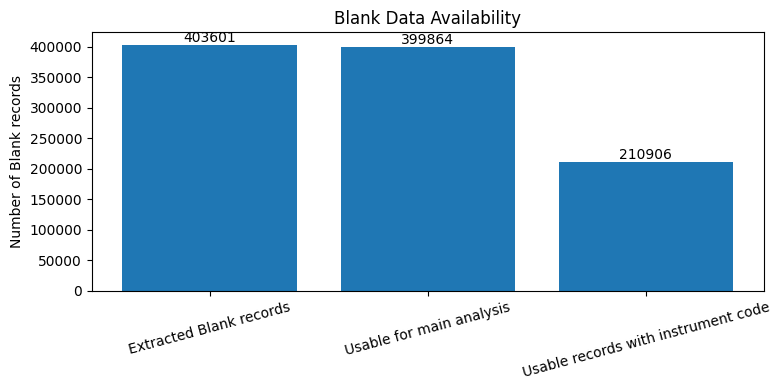

In [108]:
# Show how many Blank records are available for each part of the analysis
record_counts = {
    "Extracted Blank records": len(blank_df),
    "Usable for main analysis": len(analysis_df),
    "Usable records with instrument code": analysis_df["INSTRUMENT_CODE"].notna().sum()
}

plt.figure(figsize=(8, 4))
bars = plt.bar(record_counts.keys(), record_counts.values())

plt.ylabel("Number of Blank records")
plt.title("Blank Data Availability")

plt.bar_label(bars, fmt="%.0f")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

This step confirms that the Blank dataset is suitable for analysis and shows how much data is available for the main and instrument-level components. From here, I can start looking at the actual Blank behaviour before applying the warning, action and trend logic.

## 6. Exploratory analysis

This section provides an overview of the cleaned Blank results.

The analysis examines:

- whether results are generally close to zero;
- the number of zero, negative and positive results;
- the spread of the reported values;
- whether unusually large positive or negative results are present;
- how many analytes and instruments are represented.

No results written with a less-than sign were found in `NUMERIC_FINAL_VALUE`, so the available numeric values are used.

The overall summary combines different schemes, versions, analytes and units, so it is used only as a general overview. Later assessments compare results within the correct Scheme-Version-Analyte-Unit combination.

In [109]:
# Summarise the distribution of cleaned Blank results
blank_summary = analysis_df["NUMERIC_FINAL_VALUE"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

print("Blank result summary:")
display(blank_summary.to_frame(name="NUMERIC_FINAL_VALUE"))

# Count zero, negative and positive Blank results
zero_count = analysis_df["NUMERIC_FINAL_VALUE"].eq(0).sum()
negative_count = analysis_df["NUMERIC_FINAL_VALUE"].lt(0).sum()
positive_count = analysis_df["NUMERIC_FINAL_VALUE"].gt(0).sum()

print("Blank results equal to zero:", zero_count)
print("Negative Blank results:", negative_count)
print("Positive Blank results:", positive_count)

# Show the available analysis coverage
print("Unique schemes:", analysis_df["SCHEME_CODE"].nunique())
print("Unique scheme versions:", analysis_df["SCHEME_VERSION"].nunique())
print("Unique analytes:", analysis_df["ANALYTE_CODE"].nunique())
print("Unique units:", analysis_df["UNIT_CODE"].nunique())
print("Unique instruments available:", analysis_df["INSTRUMENT_CODE"].nunique())

Blank result summary:


,NUMERIC_FINAL_VALUE
count,399864.000000
mean,4230.225995
std,43216.406150
min,-300.445200
1%,-1.524000
5%,-0.089987
25%,0.000000
50%,0.000090
75%,0.008480
95%,1.600000


Blank results equal to zero: 133882
Negative Blank results: 62514
Positive Blank results: 203468
Unique schemes: 33
Unique scheme versions: 4
Unique analytes: 77
Unique units: 3
Unique instruments available: 8


The overall Blank results are mostly concentrated close to zero, although larger positive and negative values are also present. These values cannot yet be classified as abnormal because the summary combines different Scheme-Version-Analyte-Unit combinations. The next analysis therefore examines comparable groups separately.

In [110]:
# Examine existing CCLAS Blank status classifications
status_counts = analysis_df["STANDARD_STATUS"].value_counts(dropna=False)

print("Blank STANDARD_STATUS summary:")
display(status_counts.to_frame(name="Count"))

Blank STANDARD_STATUS summary:


,Count
STANDARD_STATUS,
Pass,384612
UpperWarning,13634
IgnoredUpperFailure,1071
LowerWarning,350
UpperFailure,195
IgnoredLowerFailure,2


Existing CCLAS status: Most Blank records are classified as Pass. The remaining records include upper and lower warnings and failures. These existing classifications provide a baseline for what CCLAS already detects; the MVP will later focus on additional patterns such as elevated trends and instrument-level patterns.

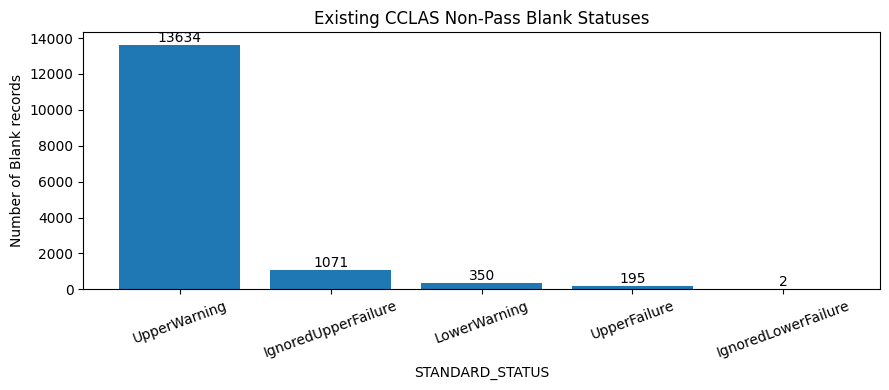

In [111]:
# Show existing non-Pass CCLAS Blank classifications
non_pass_status = status_counts.drop("Pass", errors="ignore")

plt.figure(figsize=(9, 4))

bars = plt.bar(
    non_pass_status.index,
    non_pass_status.values
)

plt.title("Existing CCLAS Non-Pass Blank Statuses")
plt.ylabel("Number of Blank records")
plt.xlabel("STANDARD_STATUS")

plt.bar_label(bars)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

This shows the existing non-Pass Blank classifications already identified by CCLAS. Upper Warnings are the most common. These statuses provide the baseline for the MVP, so the additional analysis can focus on patterns CCLAS may not currently highlight, particularly trends in results that are still individually passing.

These are the existing non-Pass Blank classifications already identified by CCLAS.

In [112]:
# Summarise existing CCLAS results by Scheme-Version-Analyte-Unit
group_columns = [
    "SCHEME_CODE",
    "SCHEME_VERSION",
    "ANALYTE_CODE",
    "UNIT_CODE",
]

group_status = (
    analysis_df
    .assign(NON_PASS=analysis_df["STANDARD_STATUS"].ne("Pass"))
    .groupby(group_columns)
    .agg(
        TOTAL_RECORDS=("STANDARD_STATUS", "size"),
        NON_PASS_RECORDS=("NON_PASS", "sum")
    )
    .reset_index()
)

group_status["NON_PASS_PERCENT"] = (
    group_status["NON_PASS_RECORDS"]
    / group_status["TOTAL_RECORDS"]
    * 100
)

group_status = group_status.sort_values(
    "NON_PASS_RECORDS",
    ascending=False
)

display(group_status.head(20))

,SCHEME_CODE,SCHEME_VERSION,ANALYTE_CODE,UNIT_CODE,TOTAL_RECORDS,NON_PASS_RECORDS,NON_PASS_PERCENT
746,PXRFRAW,2,ZR,PPM,1877,1862,99.200852
713,PXRFCOR,1,ZR,PPM,1845,1833,99.349593
722,PXRFRAW,2,FE,PPM,1875,1455,77.600000
689,PXRFCOR,1,FE,PPM,1845,1422,77.073171
732,PXRFRAW,2,RB,PPM,1877,1203,64.091636
699,PXRFCOR,1,RB,PPM,1845,1175,63.685637
712,PXRFCOR,1,ZN,PPM,1845,803,43.523035
745,PXRFRAW,2,ZN,PPM,1877,777,41.395844
739,PXRFRAW,2,TH,PPM,1876,493,26.279318
735,PXRFRAW,2,SE,PPM,1876,478,25.479744


This shows that existing CCLAS non-Pass classifications are concentrated in certain Scheme-Version-Analyte-Unit combinations. For example, almost all ZR Blank results in the PXRFCOR and PXRFRAW groups are already classified as non-Pass. This supports analysing each Scheme-Version-Analyte-Unit separately rather than applying one rule across all Blank results.

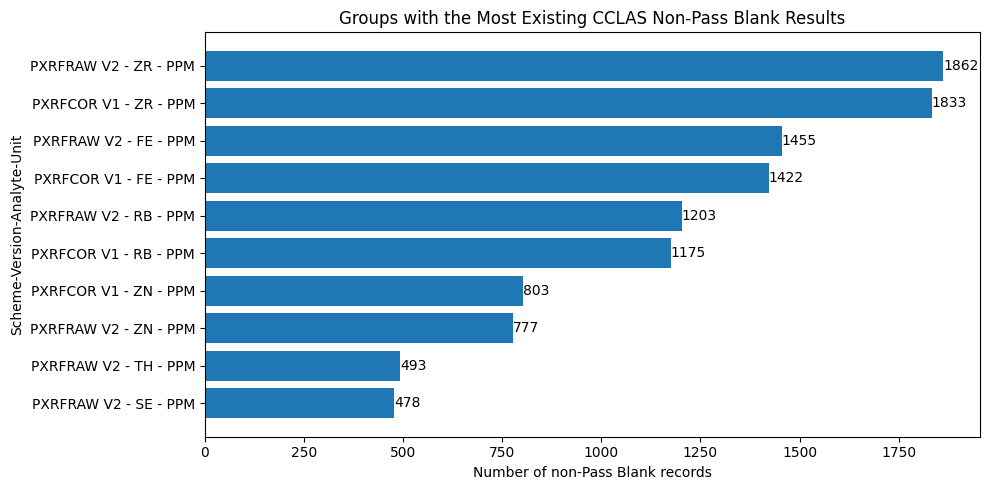

In [113]:
# Show the 10 groups with the most existing non-Pass records
top_groups = group_status.head(10).copy()

top_groups["GROUP"] = (
    top_groups["SCHEME_CODE"].astype(str)
    + " V" + top_groups["SCHEME_VERSION"].astype(str)
    + " - " + top_groups["ANALYTE_CODE"].astype(str)
    + " - " + top_groups["UNIT_CODE"].astype(str)
)

plt.figure(figsize=(10, 5))

bars = plt.barh(
    top_groups["GROUP"],
    top_groups["NON_PASS_RECORDS"]
)

plt.xlabel("Number of non-Pass Blank records")
plt.ylabel("Scheme-Version-Analyte-Unit")
plt.title("Groups with the Most Existing CCLAS Non-Pass Blank Results")

plt.bar_label(bars)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

This graph shows which Scheme-Version-Analyte-Unit groups contain the largest number of Blank results already classified as non-Pass by CCLAS. ZR has the highest counts, with 1,862 non-Pass results in PXRFRAW V2 and 1,833 in PXRFCOR V1. This shows that existing non-Pass classifications are concentrated in particular Blank groups and supports analysing each Scheme-Version-Analyte-Unit separately rather than treating all Blank results the same.

### Instrument-level Blank summary

Datamine indicated that instruments with more non-Pass Blank results should be highlighted in the final summary.

The following analysis compares the existing CCLAS non-Pass classifications across records with an available instrument code. Blank limits are not instrument-specific, so this is used only to identify whether some instruments have more non-Pass Blank results than others.

In [114]:
# Summarise existing CCLAS results by instrument
instrument_df = analysis_df[
    analysis_df["INSTRUMENT_CODE"].notna()
].copy()

instrument_summary = (
    instrument_df
    .assign(NON_PASS=instrument_df["STANDARD_STATUS"].ne("Pass"))
    .groupby("INSTRUMENT_CODE")
    .agg(
        TOTAL_RECORDS=("STANDARD_STATUS", "size"),
        NON_PASS_RECORDS=("NON_PASS", "sum")
    )
    .reset_index()
)

instrument_summary["NON_PASS_PERCENT"] = (
    instrument_summary["NON_PASS_RECORDS"]
    / instrument_summary["TOTAL_RECORDS"]
    * 100
)

instrument_summary = instrument_summary.sort_values(
    "NON_PASS_RECORDS",
    ascending=False
)

display(instrument_summary)

,INSTRUMENT_CODE,TOTAL_RECORDS,NON_PASS_RECORDS,NON_PASS_PERCENT
7,PXRF_IMPORT,64583,7383,11.431801
4,PE_ICPMS,62986,174,0.276252
5,PE_ICPOES,16286,99,0.607884
2,AGILENT_ICPMS,45540,40,0.087835
6,PHOTON,31,14,45.161290
0,AGILENT_AAS,10903,2,0.018344
1,AGILENT_AAS_2,10396,0,0.000000
3,INDF_CS,181,0,0.000000


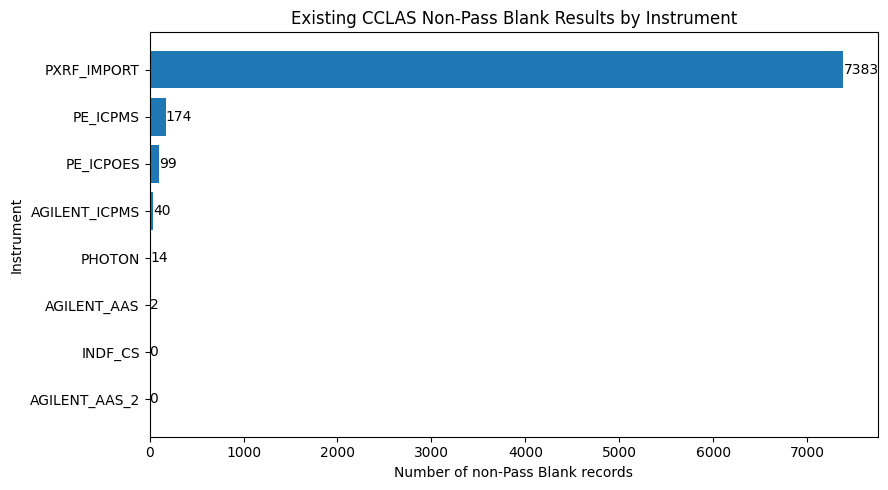

In [115]:
# Visualise existing CCLAS non-Pass results by instrument
plot_data = instrument_summary.sort_values(
    "NON_PASS_RECORDS",
    ascending=True
)

plt.figure(figsize=(9, 5))

bars = plt.barh(
    plot_data["INSTRUMENT_CODE"],
    plot_data["NON_PASS_RECORDS"]
)

plt.xlabel("Number of non-Pass Blank records")
plt.ylabel("Instrument")
plt.title("Existing CCLAS Non-Pass Blank Results by Instrument")

plt.bar_label(bars)
plt.tight_layout()
plt.show()

PXRF_IMPORT has the highest number of existing CCLAS non-Pass Blank results, with 7,383 out of 64,583 records (11.43%). PHOTON has the highest percentage at 45.16%, but this is based on only 31 records. This identifies instrument-level patterns in the existing CCLAS classifications for the summary, but does not indicate that different Blank limits should be applied to different instruments.

CCLAS already flags individual failures, but the client also wants elevated behaviour as a trend while the individual results may still be passing.

## 7. Blank feature engineering

Features are created within each Scheme-Version-Analyte-Unit combination so that Blank results are compared with the relevant group rather than with unrelated Blank data.

The features describe the previous result, change between consecutive results, typical group behaviour and distance from the group median.

No new Warning or Action thresholds are created in this section. The numerical Blank limits are not currently available in the supplied data.

In [116]:
# Remove old feature columns from the previous version
old_feature_columns = [
    "TARGET_DEVIATION",
    "ZERO_MAD_GROUP",
    "ROBUST_Z_SCORE",
    "ROLLING_MEDIAN",
    "ROLLING_CHANGE",
]

analysis_df = analysis_df.drop(
    columns=old_feature_columns,
    errors="ignore"
)

# Define the correct Blank comparison groups
GROUP_COLUMNS = [
    "SCHEME_CODE",
    "SCHEME_VERSION",
    "ANALYTE_CODE",
    "UNIT_CODE",
]

# Keep each comparison group in chronological order
analysis_df = analysis_df.sort_values(
    GROUP_COLUMNS + ["ANALYSED_DATE"]
).copy()

# Previous result within the same group
analysis_df["PREVIOUS_VALUE"] = (
    analysis_df
    .groupby(GROUP_COLUMNS)["NUMERIC_FINAL_VALUE"]
    .shift(1)
)

# Change from the previous result
analysis_df["CHANGE_FROM_PREVIOUS"] = (
    analysis_df["NUMERIC_FINAL_VALUE"]
    - analysis_df["PREVIOUS_VALUE"]
)

# Size of the change, regardless of direction
analysis_df["ABS_CHANGE_FROM_PREVIOUS"] = (
    analysis_df["CHANGE_FROM_PREVIOUS"].abs()
)

# Typical value within each Scheme-Version-Analyte-Unit group
analysis_df["GROUP_MEDIAN"] = (
    analysis_df
    .groupby(GROUP_COLUMNS)["NUMERIC_FINAL_VALUE"]
    .transform("median")
)

# Distance from the typical group value
analysis_df["ABS_MEDIAN_DEVIATION"] = (
    analysis_df["NUMERIC_FINAL_VALUE"]
    - analysis_df["GROUP_MEDIAN"]
).abs()

# Typical variation within each group
analysis_df["GROUP_MAD"] = (
    analysis_df
    .groupby(GROUP_COLUMNS)["ABS_MEDIAN_DEVIATION"]
    .transform("median")
)

# Number of Blank results available in each group
analysis_df["GROUP_SIZE"] = (
    analysis_df
    .groupby(GROUP_COLUMNS)["NUMERIC_FINAL_VALUE"]
    .transform("size")
)

print("Blank feature engineering complete.")

display(
    analysis_df[
        GROUP_COLUMNS
        + [
            "ANALYSED_DATE",
            "NUMERIC_FINAL_VALUE",
            "PREVIOUS_VALUE",
            "CHANGE_FROM_PREVIOUS",
            "ABS_CHANGE_FROM_PREVIOUS",
            "GROUP_MEDIAN",
            "ABS_MEDIAN_DEVIATION",
            "GROUP_MAD",
            "GROUP_SIZE",
        ]
    ].head(10)
)

Blank feature engineering complete.


,SCHEME_CODE,SCHEME_VERSION,ANALYTE_CODE,UNIT_CODE,ANALYSED_DATE,NUMERIC_FINAL_VALUE,PREVIOUS_VALUE,CHANGE_FROM_PREVIOUS,ABS_CHANGE_FROM_PREVIOUS,GROUP_MEDIAN,ABS_MEDIAN_DEVIATION,GROUP_MAD,GROUP_SIZE
0,AR10_AU,1,AU,PPB,2019-07-04 07:57:11,-0.47114,NaN,NaN,NaN,-0.16225,0.30889,0.29323,1089
1,AR10_AU,1,AU,PPB,2019-08-14 10:03:59,-0.50287,-0.47114,-0.03173,0.03173,-0.16225,0.34062,0.29323,1089
2,AR10_AU,1,AU,PPB,2019-08-14 10:04:43,-0.24679,-0.50287,0.25608,0.25608,-0.16225,0.08454,0.29323,1089
3,AR10_AU,1,AU,PPB,2019-08-14 10:05:28,-0.34447,-0.24679,-0.09768,0.09768,-0.16225,0.18222,0.29323,1089
4,AR10_AU,1,AU,PPB,2019-08-14 10:07:16,-0.50210,-0.34447,-0.15763,0.15763,-0.16225,0.33985,0.29323,1089
5,AR10_AU,1,AU,PPB,2019-08-14 10:43:09,0.03274,-0.50210,0.53484,0.53484,-0.16225,0.19499,0.29323,1089
6,AR10_AU,1,AU,PPB,2019-08-14 14:24:29,-0.10969,0.03274,-0.14243,0.14243,-0.16225,0.05256,0.29323,1089
7,AR10_AU,1,AU,PPB,2019-08-15 07:27:05,-1.00017,-0.10969,-0.89048,0.89048,-0.16225,0.83792,0.29323,1089
8,AR10_AU,1,AU,PPB,2019-08-15 07:31:17,-1.30955,-1.00017,-0.30938,0.30938,-0.16225,1.14730,0.29323,1089
9,AR10_AU,1,AU,PPB,2019-08-15 07:35:30,-2.04846,-1.30955,-0.73891,0.73891,-0.16225,1.88621,0.29323,1089


Refer to table
These features describe how each Blank result behaves over time and relative to its own Scheme-Version-Analyte-Unit history. They do not classify a result as a Warning, Failure or anomaly. Instead, they prepare the data for the later trend and anomaly-detection stages.


The engineered features compare Blank results within the same scheme, analyte and unit.

The Z-score identifies individual results that are unusually high compared with normal group behaviour. The rolling median tracks the local Blank baseline over time and supports the identification of elevated collective behaviour.

Missing rolling values at the beginning of some groups are expected because at least three results are required. These features identify candidate unusual behaviour and do not confirm contamination.

## 8. Blank anomaly assessment

This section assesses three Blank anomaly patterns:

- **Point anomalies:** unusual individual Blank results.
- **Collective anomalies:** trends across multiple Blank results.
- **Contextual anomalies:** unusual behaviour linked to particular instruments.

CCLAS already flags individual Warning and Failure results. This MVP focuses on additional trend and anomaly behaviour.

No new QC thresholds are created because the numerical Warning and Action limits are not available. Any trend rules used later are treated as POC methods, not Datamine-defined rules.

In [117]:
analysis_df["CCLAS_NON_PASS"] = (
    analysis_df["STANDARD_STATUS"]
    .fillna("Unknown")
    .ne("Pass")
)

analysis_df["TREND_DATA_AVAILABLE"] = (
    analysis_df["PREVIOUS_VALUE"].notna()
)

INSTRUMENT_GROUP_COLUMNS = GROUP_COLUMNS + ["INSTRUMENT_CODE"]

analysis_df["INSTRUMENT_MEDIAN"] = (
    analysis_df
    .groupby(
        INSTRUMENT_GROUP_COLUMNS,
        dropna=False
    )["NUMERIC_FINAL_VALUE"]
    .transform("median")
)

analysis_df["INSTRUMENT_MEDIAN_DIFFERENCE"] = (
    analysis_df["INSTRUMENT_MEDIAN"]
    - analysis_df["GROUP_MEDIAN"]
)

print(
    "Existing CCLAS non-Pass Blank results:",
    analysis_df["CCLAS_NON_PASS"].sum()
)

print(
    "Rows available for consecutive-result trend analysis:",
    analysis_df["TREND_DATA_AVAILABLE"].sum()
)

print(
    "Rows with instrument information:",
    analysis_df["INSTRUMENT_CODE"].notna().sum()
)

Existing CCLAS non-Pass Blank results: 15252
Rows available for consecutive-result trend analysis: 399113
Rows with instrument information: 210906


## 9. Pending Datamine clarification

`STANDARD_STATUS` is currently used as the existing CCLAS rule-based baseline, while the POC focuses on identifying additional trend and anomaly behaviour.

Questions for Datamine:

- Is using `STANDARD_STATUS` as the existing CCLAS baseline sufficient for the Blank POC, with the new analysis focused on trends and anomalies not already highlighted by CCLAS?
- Which field identifies a single QC batch for Blank alerting?
- How should `IgnoredUpperFailure` and `IgnoredLowerFailure` be interpreted in the POC?

## 10. Machine learning anomaly detection

